# PC MA2024 BrainCell step-by-step tutorial

这个 notebook 用 Purkinje cell (PC) MA2024 作为例子，展示如何在 BrainCell 里一步步构建一个复杂树突模型。

它刻意不把流程封装成 `PC` 类，而是把 `pc_braincell.py` 中的动作拆开：导入 morphology、定义 region、检查 region、paint cable、paint ion、paint channel、放置 probe/stimulus，最后运行模型。每一步后面都有一个可检查的输出。

In [1]:
from pathlib import Path
import os
import sys
import math
from collections import Counter

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import brainunit as u
import brainstate
from braincell import Cell, Morphology, mech
from braincell._discretization.policy import CVPerBranchList
from braincell.filter import AllRegion, at, branch_in, branch_range
from braincell.vis import plot2d

from examples.neuron_compare.cell.pc_ma2024.parameters import (
    DEFAULT_MORPH_PATH,
    PCCableParameters,
    load_pc24_params,
    pc24_nseg_rule,
)

brainstate.environ.set(precision=64)
plt.rcParams["figure.dpi"] = 120

print(f"repo root: {REPO_ROOT}")
print(f"morphology path: {DEFAULT_MORPH_PATH}")

repo root: /home/swl/braincell-ion_dyn
morphology path: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/morphology/PC.asc


## 1. 读取 PC 参数

`parameters.py` 把原始 population row 解析成三组参数：channel、cable、ion。教程里直接复用这些参数，避免把注意力放在数据文件解析上。

In [2]:
params = load_pc24_params()
cable = params.cable
ion = params.ion
ch = params.channel

dt_ms = 0.1
duration_ms = 20.0
delay_ms = 5.0
stim_dur_ms = 10.0
amp_nA = 0.5
temperature_celsius = 36.0
v_init_mV = -65.0
temp = u.celsius2kelvin(temperature_celsius)

print("parameter indiv:", params.channel.indiv)
print("cable:", cable.to_dict())
print("ion:", ion.to_dict())
print("soma channel sample:", {k: ch.soma.to_dict()[k] for k in ["nav1p6", "kv1p1", "cav2p1_perm", "hcn1"]})
print("dend channel sample:", {k: ch.dend.to_dict()[k] for k in ["nav1p6", "kv3p3", "cav2p1_perm", "hcn1"]})

parameter indiv: 138
cable: {'ra_ohm_cm': 122.0, 'leak_e_mV': -61.0, 'soma_cm_uF_cm2': 2.0, 'leak_g_soma_mS_cm2': 1.0, 'leak_g_dend_mS_cm2': 0.3, 'thick_dend_diam_um': 1.6, 'nav_dend_diam_um': 3.3, 'cv_max_len_um': 40.0}
ion: {'na_e_mV': 60.0, 'k_e_mV': -88.0, 'h_e_mV': -34.4, 'ca_e_mV': 137.52625, 'cdp_pump_soma': 5e-08, 'cdp_pump_dend': 6e-08}
soma channel sample: {'nav1p6': 0.19852881401896, 'kv1p1': 0.00125920049117, 'cav2p1_perm': 0.00031927816343, 'hcn1': 0.00103978277412}
dend channel sample: {'nav1p6': 0.0149257607701, 'kv3p3': 0.00908247993868, 'cav2p1_perm': 0.0011450738062800002, 'hcn1': 2.35833545e-06}


## 2. 导入 morphology

NEURON 版本使用 `Import3d_Neurolucida3` 读取同一个 ASC 文件。BrainCell 里对应的是 `Morphology.from_asc(...)`。导入后先确认 branch 数量、类型、长度和直径范围。

In [3]:
morph = Morphology.from_asc(DEFAULT_MORPH_PATH)

def branch_table(morph, n=8):
    rows = []
    for branch in morph.branches[:n]:
        rows.append({
            "index": int(branch.index),
            "name": branch.name,
            "type": branch.type,
            "length_um": float(np.asarray(branch.length.to_decimal(u.um), dtype=float)),
            "diam_arc_mean_um": float(np.asarray(branch.diam_arc_mean.to_decimal(u.um), dtype=float)),
        })
    return rows

lengths_um = np.asarray([branch.length.to_decimal(u.um) for branch in morph.branches], dtype=float)
diams_um = np.asarray([branch.diam_arc_mean.to_decimal(u.um) for branch in morph.branches], dtype=float)

print("branch count:", len(morph.branches))
print("branch types:", Counter(branch.type for branch in morph.branches))
print("length range (um):", float(np.nanmin(lengths_um)), float(np.nanmax(lengths_um)))
print("diameter range (um):", float(np.nanmin(diams_um)), float(np.nanmax(diams_um)))
branch_table(morph)

--No graphics will be displayed.
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [6]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [8]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [4]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/read

branch count: 461
branch types: Counter({'dendrite': 460, 'soma': 1})
length range (um): 0.38000000000010914 59.08586240904042
diameter range (um): 0.51 15.744262808855295


[{'index': 0,
  'name': 'soma',
  'type': 'soma',
  'length_um': 19.960573505972423,
  'diam_arc_mean_um': 15.744262808855295},
 {'index': 1,
  'name': 'dendrite_0',
  'type': 'dendrite',
  'length_um': 24.80292244968256,
  'diam_arc_mean_um': 3.626054505995911},
 {'index': 2,
  'name': 'dendrite_1',
  'type': 'dendrite',
  'length_um': 21.002666897616436,
  'diam_arc_mean_um': 1.8999999999999995},
 {'index': 3,
  'name': 'dendrite_2',
  'type': 'dendrite',
  'length_um': 5.759764553594964,
  'diam_arc_mean_um': 1.9},
 {'index': 4,
  'name': 'dendrite_3',
  'type': 'dendrite',
  'length_um': 18.118822951182672,
  'diam_arc_mean_um': 1.3424878767329276},
 {'index': 5,
  'name': 'dendrite_4',
  'type': 'dendrite',
  'length_um': 16.660481469208356,
  'diam_arc_mean_um': 0.63},
 {'index': 6,
  'name': 'dendrite_5',
  'type': 'dendrite',
  'length_um': 10.76037645181857,
  'diam_arc_mean_um': 0.6300000000000001},
 {'index': 7,
  'name': 'dendrite_6',
  'type': 'dendrite',
  'length_um': 3.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


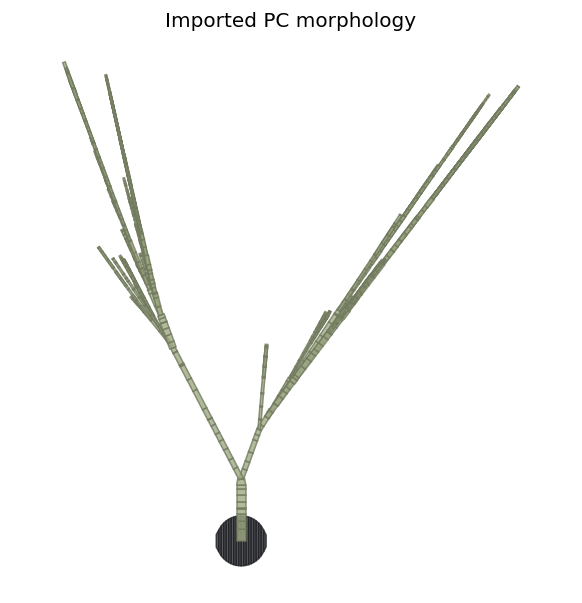

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
plot2d(morph, layout="fan", shape="frustum", ax=ax)
ax.set_title("Imported PC morphology")
plt.show()

## 3. 选择 CV 离散化规则并创建 Cell

PC 的 NEURON 模板里每个 section 使用 `nseg = 1 + 2 * int(L / CV_MAX_LEN_UM)`。这里把同一规则变成每个 branch 的 CV 数量，然后交给 `CVPerBranchList`。

In [5]:
def pc24_dend_cm(diam_arc_mean_um: float, cable: PCCableParameters) -> float:
    diam = float(diam_arc_mean_um)
    if diam >= cable.thick_dend_diam_um:
        return cable.soma_cm_uF_cm2
    return 11.510294 * math.exp(-1.376463 * diam) + 2.120503


def cv_count_for_branch(branch, cable: PCCableParameters) -> int:
    length_um = float(np.asarray(branch.length.to_decimal(u.um), dtype=float))
    return pc24_nseg_rule(length_um, max_len_um=cable.cv_max_len_um)

cv_counts = tuple(cv_count_for_branch(branch, cable) for branch in morph.branches)
cell = Cell(
    morph,
    cv_policy=CVPerBranchList(cv_counts),
    V_init=v_init_mV * u.mV,
    solver="staggered",
)

print("branch count:", len(morph.branches))
print("CV count:", cell.n_cv)
print("first CV counts:", cv_counts[:12])
[
    {
        "branch": branch.name,
        "length_um": round(float(np.asarray(branch.length.to_decimal(u.um), dtype=float)), 3),
        "n_cv": cv_counts[i],
    }
    for i, branch in enumerate(morph.branches[:8])
]

branch count: 461
CV count: 465
first CV counts: (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)


[{'branch': 'soma', 'length_um': 19.961, 'n_cv': 1},
 {'branch': 'dendrite_0', 'length_um': 24.803, 'n_cv': 1},
 {'branch': 'dendrite_1', 'length_um': 21.003, 'n_cv': 1},
 {'branch': 'dendrite_2', 'length_um': 5.76, 'n_cv': 1},
 {'branch': 'dendrite_3', 'length_um': 18.119, 'n_cv': 1},
 {'branch': 'dendrite_4', 'length_um': 16.66, 'n_cv': 1},
 {'branch': 'dendrite_5', 'length_um': 10.76, 'n_cv': 1},
 {'branch': 'dendrite_6', 'length_um': 3.718, 'n_cv': 1}]

## 4. 定义 region

Region 是后续 paint 的目标。这里定义四个区域：soma、所有 dendrite、粗树突、以及能插入 dendritic Nav1.6 的更粗树突。

In [6]:
dend_region = branch_in("type", "dendrite")
regions = {
    "soma": branch_in("type", "soma"),
    "dend": dend_region,
    "thick_dend": dend_region
    & branch_range("diam_arc_mean", (cable.thick_dend_diam_um * u.um, None), closed="left"),
    "nav_dend": dend_region
    & branch_range("diam_arc_mean", (cable.nav_dend_diam_um * u.um, None), closed="left"),
}

def region_summary(name, region, morph, n=6):
    intervals = region.evaluate(morph).intervals
    branch_ids = [int(branch_id) for branch_id, _, _ in intervals]
    return {
        "region": name,
        "interval_count": len(intervals),
        "branch_count": len(set(branch_ids)),
        "sample_branches": [morph.branches[i].name for i in branch_ids[:n]],
    }

[region_summary(name, region, morph) for name, region in regions.items()]

[{'region': 'soma',
  'interval_count': 1,
  'branch_count': 1,
  'sample_branches': ['soma']},
 {'region': 'dend',
  'interval_count': 460,
  'branch_count': 460,
  'sample_branches': ['dendrite_0',
   'dendrite_1',
   'dendrite_2',
   'dendrite_3',
   'dendrite_4',
   'dendrite_5']},
 {'region': 'thick_dend',
  'interval_count': 26,
  'branch_count': 26,
  'sample_branches': ['dendrite_0',
   'dendrite_1',
   'dendrite_2',
   'dendrite_18',
   'dendrite_19',
   'dendrite_26']},
 {'region': 'nav_dend',
  'interval_count': 1,
  'branch_count': 1,
  'sample_branches': ['dendrite_0']}]

## 5. 可视化 region

下面的图用于确认 region selector 选中了预期分支。`vis_branch` 在 branch topology 上高亮 region，适合检查粗树突和 Nav dendrite 这种小区域。

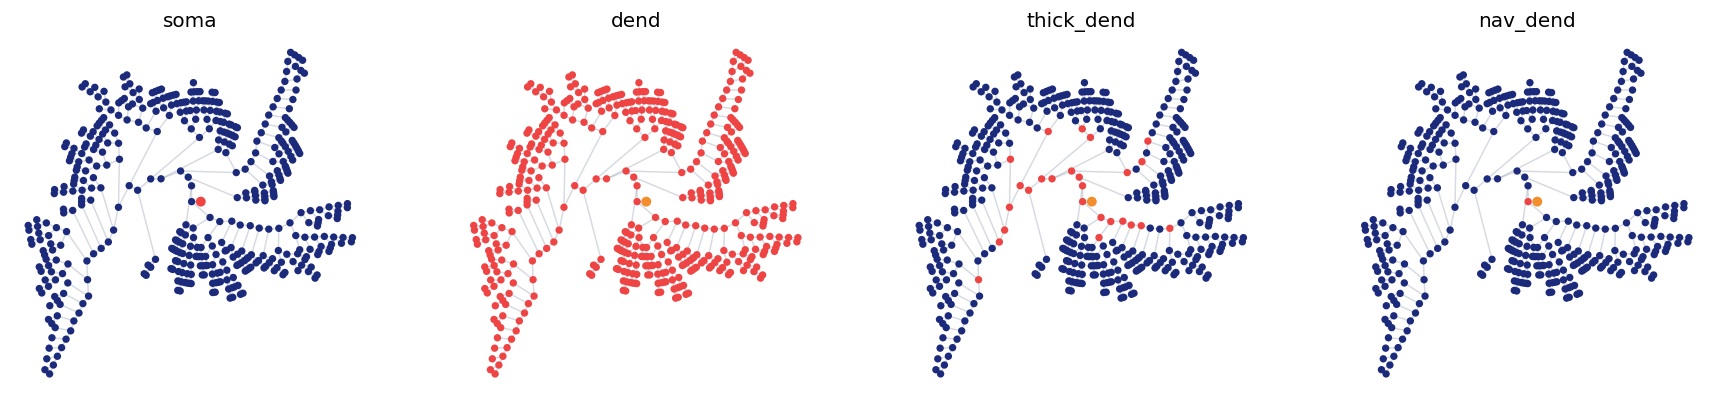

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (name, region) in zip(axes, regions.items()):
    cell.vis_branch(region=region, coverage_mode="any", ax=ax, show=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 6. Paint passive cable properties

先 paint 一个全局默认 cable，然后逐 branch 覆盖真实的 `Ra/cm/e_pas`。这样和 NEURON 里逐 section 赋值的方式最接近，也能表达 dendrite capacitance 随直径变化的规则。

In [8]:
cell.paint(
    AllRegion(),
    mech.CableProperty(
        resting_potential=cable.leak_e_mV * u.mV,
        membrane_capacitance=cable.soma_cm_uF_cm2 * (u.uF / u.cm**2),
        axial_resistivity=cable.ra_ohm_cm * (u.ohm * u.cm),
    ),
)

cable_rows = []
for branch in morph.branches:
    diam_um = float(np.asarray(branch.diam_arc_mean.to_decimal(u.um), dtype=float))
    cm_value = cable.soma_cm_uF_cm2 if branch.type == "soma" else pc24_dend_cm(diam_um, cable)
    cell.paint(
        branch_in("name", branch.name),
        mech.CableProperty(
            resting_potential=cable.leak_e_mV * u.mV,
            membrane_capacitance=cm_value * (u.uF / u.cm**2),
            axial_resistivity=cable.ra_ohm_cm * (u.ohm * u.cm),
        ),
    )
    if len(cable_rows) < 8 or diam_um >= cable.thick_dend_diam_um:
        cable_rows.append({
            "branch": branch.name,
            "type": branch.type,
            "diam_arc_mean_um": round(diam_um, 4),
            "cm_uF_cm2": round(float(cm_value), 6),
        })

print("paint rules after cable:", len(cell.paint_rules))
cable_rows[:12]

paint rules after cable: 462


[{'branch': 'soma',
  'type': 'soma',
  'diam_arc_mean_um': 15.7443,
  'cm_uF_cm2': 2.0},
 {'branch': 'dendrite_0',
  'type': 'dendrite',
  'diam_arc_mean_um': 3.6261,
  'cm_uF_cm2': 2.0},
 {'branch': 'dendrite_1',
  'type': 'dendrite',
  'diam_arc_mean_um': 1.9,
  'cm_uF_cm2': 2.0},
 {'branch': 'dendrite_2',
  'type': 'dendrite',
  'diam_arc_mean_um': 1.9,
  'cm_uF_cm2': 2.0},
 {'branch': 'dendrite_3',
  'type': 'dendrite',
  'diam_arc_mean_um': 1.3425,
  'cm_uF_cm2': 3.934181},
 {'branch': 'dendrite_4',
  'type': 'dendrite',
  'diam_arc_mean_um': 0.63,
  'cm_uF_cm2': 6.956417},
 {'branch': 'dendrite_5',
  'type': 'dendrite',
  'diam_arc_mean_um': 0.63,
  'cm_uF_cm2': 6.956417},
 {'branch': 'dendrite_6',
  'type': 'dendrite',
  'diam_arc_mean_um': 0.63,
  'cm_uF_cm2': 6.956417},
 {'branch': 'dendrite_18',
  'type': 'dendrite',
  'diam_arc_mean_um': 1.9,
  'cm_uF_cm2': 2.0},
 {'branch': 'dendrite_19',
  'type': 'dendrite',
  'diam_arc_mean_um': 1.6935,
  'cm_uF_cm2': 2.0},
 {'branch': 

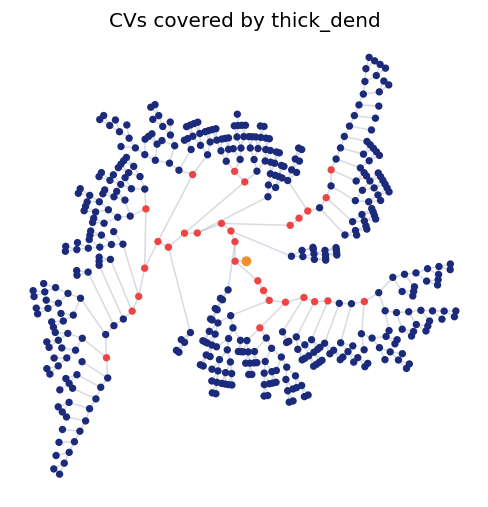

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
cell.vis_cv(region=regions["thick_dend"], coverage_mode="any", ax=ax, show=False)
ax.set_title("CVs covered by thick_dend")
plt.show()

## 7. Paint ions

BrainCell 先声明 ion，再声明依赖这些 ion 的 channel。这里全局 paint fixed Na/K，Ca 使用 PC24 的 dynamic calcium pump，并给 soma/dend 不同的 pump density。

In [10]:
cell.paint(AllRegion(), mech.Ion("SodiumFixed", name="na", E=ion.na_e_mV * u.mV))
cell.paint(AllRegion(), mech.Ion("PotassiumFixed", name="k", E=ion.k_e_mV * u.mV))
cell.paint(
    regions["soma"],
    mech.Ion(
        "CdpCAM_MA2024_PC",
        name="ca",
        temp=temp,
        Co=2.0 * u.mM,
        Ci_initializer=45e-6 * u.mM,
        TotalPump=ion.cdp_pump_soma * (u.mol / u.cm**2),
    ),
)
cell.paint(
    regions["dend"],
    mech.Ion(
        "CdpCAM_MA2024_PC",
        name="ca",
        temp=temp,
        Co=2.0 * u.mM,
        Ci_initializer=45e-6 * u.mM,
        TotalPump=ion.cdp_pump_dend * (u.mol / u.cm**2),
    ),
)

ion_rules = [rule for rule in cell.paint_rules if getattr(rule.mechanism, "category", None) == "ion"]
print("ion paint rules:", len(ion_rules))
[
    {
        "class_name": rule.mechanism.class_name,
        "name": rule.mechanism.name,
        "params": list(rule.mechanism.params.keys()),
        "interval_count": len(rule.region.evaluate(morph).intervals),
    }
    for rule in ion_rules
]

ion paint rules: 4


[{'class_name': 'SodiumFixed',
  'name': 'na',
  'params': ['E'],
  'interval_count': 461},
 {'class_name': 'PotassiumFixed',
  'name': 'k',
  'params': ['E'],
  'interval_count': 461},
 {'class_name': 'CdpCAM_MA2024_PC',
  'name': 'ca',
  'params': ['temp', 'Co', 'Ci_initializer', 'TotalPump'],
  'interval_count': 1},
 {'class_name': 'CdpCAM_MA2024_PC',
  'name': 'ca',
  'params': ['temp', 'Co', 'Ci_initializer', 'TotalPump'],
  'interval_count': 460}]

## 8. Paint ion channels

Channel paint 分四块写：soma、dendrite base、thick dendrite、nav dendrite。这样读者可以直接和 `pc_neuron.py` 中的 `insert` 逻辑对照。

In [11]:
soma_channels = (
    mech.Channel("IL", g_max=cable.leak_g_soma_mS_cm2 * (u.mS / u.cm**2), E=cable.leak_e_mV * u.mV),
    mech.Channel("Nav1p6_MA2024_PC", g_max=ch.soma.nav1p6 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kv1p1_MA2024_PC", g_max=ch.soma.kv1p1 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kv1p5_MA2024_PC", g_max=ch.soma.kv1p5 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kv3p4_MA2024_PC", g_max=ch.soma.kv3p4 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kir2p3_MA2024_PC", g_max=ch.soma.kir2p3 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kca1p1_MA2024_PC", g_max=ch.soma.kca1p1 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kca2p2_MA2024_PC", g_max=ch.soma.kca2p2 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kca3p1_MA2024_PC", g_max=ch.soma.kca3p1 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Cav2p1_MA2024_PC_Frozen", g_max=ch.soma.cav2p1_perm * (u.cm / u.second), temp=temp),
    mech.Channel("Cav3p1_MA2024_PC_Frozen", g_max=ch.soma.cav3p1_perm * (u.cm / u.second), temp=temp),
    mech.Channel("Cav3p2_MA2024_PC", g_max=ch.soma.cav3p2 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel(
        "Cav3p3_MA2024_PC_Frozen",
        perm=ch.soma.cav3p3_perm * (u.cm / u.second),
        g_scale=ch.cav3p3_g_scale,
        temp=temp,
    ),
    mech.Channel("HCN1_MA2024_PC", g_max=ch.soma.hcn1 * (u.siemens / u.cm**2), E=ion.h_e_mV * u.mV, temp=temp),
)
cell.paint(regions["soma"], *soma_channels)

print("soma channel count:", len(soma_channels))
[m.class_name for m in soma_channels]

soma channel count: 14


['IL',
 'Nav1p6_MA2024_PC',
 'Kv1p1_MA2024_PC',
 'Kv1p5_MA2024_PC',
 'Kv3p4_MA2024_PC',
 'Kir2p3_MA2024_PC',
 'Kca1p1_MA2024_PC',
 'Kca2p2_MA2024_PC',
 'Kca3p1_MA2024_PC',
 'Cav2p1_MA2024_PC_Frozen',
 'Cav3p1_MA2024_PC_Frozen',
 'Cav3p2_MA2024_PC',
 'Cav3p3_MA2024_PC_Frozen',
 'HCN1_MA2024_PC']

In [12]:
dend_base_channels = (
    mech.Channel("IL", g_max=cable.leak_g_dend_mS_cm2 * (u.mS / u.cm**2), E=cable.leak_e_mV * u.mV),
    mech.Channel("Kv3p3_MA2024_PC", g_max=ch.dend.kv3p3 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kv4p3_MA2024_PC", g_max=ch.dend.kv4p3 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kca1p1_MA2024_PC", g_max=ch.dend.kca1p1 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kca2p2_MA2024_PC", g_max=ch.dend.kca2p2 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Cav2p1_MA2024_PC_Frozen", g_max=ch.dend.cav2p1_perm * (u.cm / u.second), temp=temp),
    mech.Channel(
        "Cav3p3_MA2024_PC_Frozen",
        perm=ch.dend.cav3p3_perm * (u.cm / u.second),
        g_scale=ch.cav3p3_g_scale,
        temp=temp,
    ),
    mech.Channel("HCN1_MA2024_PC", g_max=ch.dend.hcn1 * (u.siemens / u.cm**2), E=ion.h_e_mV * u.mV, temp=temp),
)
cell.paint(regions["dend"], *dend_base_channels)

print("dend base channel count:", len(dend_base_channels))
[m.class_name for m in dend_base_channels]

dend base channel count: 8


['IL',
 'Kv3p3_MA2024_PC',
 'Kv4p3_MA2024_PC',
 'Kca1p1_MA2024_PC',
 'Kca2p2_MA2024_PC',
 'Cav2p1_MA2024_PC_Frozen',
 'Cav3p3_MA2024_PC_Frozen',
 'HCN1_MA2024_PC']

In [13]:
thick_dend_channels = (
    mech.Channel("Kv1p1_MA2024_PC", g_max=ch.dend.kv1p1 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kv1p5_MA2024_PC", g_max=ch.dend.kv1p5 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kir2p3_MA2024_PC", g_max=ch.dend.kir2p3 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Kca3p1_MA2024_PC", g_max=ch.dend.kca3p1 * (u.siemens / u.cm**2), temp=temp),
    mech.Channel("Cav3p1_MA2024_PC_Frozen", g_max=ch.dend.cav3p1_perm * (u.cm / u.second), temp=temp),
    mech.Channel("Cav3p2_MA2024_PC", g_max=ch.dend.cav3p2 * (u.siemens / u.cm**2), temp=temp),
)
cell.paint(regions["thick_dend"], *thick_dend_channels)

nav_dend_channels = (
    mech.Channel("Nav1p6_MA2024_PC", g_max=ch.dend.nav1p6 * (u.siemens / u.cm**2), temp=temp),
)
cell.paint(regions["nav_dend"], *nav_dend_channels)

channel_rules = [rule for rule in cell.paint_rules if getattr(rule.mechanism, "category", None) == "channel"]
print("total channel paint rules:", len(channel_rules))
print("total paint rules:", len(cell.paint_rules))
Counter(rule.mechanism.class_name for rule in channel_rules)

total channel paint rules: 29
total paint rules: 495


Counter({'IL': 2,
         'Nav1p6_MA2024_PC': 2,
         'Kv1p1_MA2024_PC': 2,
         'Kv1p5_MA2024_PC': 2,
         'Kir2p3_MA2024_PC': 2,
         'Kca1p1_MA2024_PC': 2,
         'Kca2p2_MA2024_PC': 2,
         'Kca3p1_MA2024_PC': 2,
         'Cav2p1_MA2024_PC_Frozen': 2,
         'Cav3p1_MA2024_PC_Frozen': 2,
         'Cav3p2_MA2024_PC': 2,
         'Cav3p3_MA2024_PC_Frozen': 2,
         'HCN1_MA2024_PC': 2,
         'Kv3p4_MA2024_PC': 1,
         'Kv3p3_MA2024_PC': 1,
         'Kv4p3_MA2024_PC': 1})

## 9. 放置 probe 和 current clamp

`place()` 和 `paint()` 都属于声明阶段，必须在 `init_state()` 前完成。这里在 soma 0.5 放一个 voltage probe 和一个 step current clamp。

In [14]:
cell.place(at("soma", 0.5), mech.StateProbe(name="v_soma"))
cell.place(
    at("soma", 0.5),
    mech.CurrentClamp(delay=delay_ms * u.ms, durations=stim_dur_ms * u.ms, amplitudes=amp_nA * u.nA),
)

print("place rules:", len(cell.place_rules))
[
    {
        "locset": type(rule.locset).__name__,
        "mechanisms": [type(m).__name__ for m in rule.mechanisms],
    }
    for rule in cell.place_rules
]

place rules: 2


[{'locset': 'AtLocation', 'mechanisms': ['StateProbe']},
 {'locset': 'AtLocation', 'mechanisms': ['CurrentClamp']}]

## 10. 初始化 runtime 并检查 layout

`init_state()` 会把声明阶段的 paint/place 降低到 CV 和 runtime node。检查 layout 可以确认 channel、ion、clamp、probe 都进入了模型。

In [15]:
cell.init_state()
cell.reset_state()

layout_counts = Counter(layout.kind for layout in cell.runtime.layouts)
print("n_cv:", cell.n_cv)
print("n_point:", cell.n_point)
print("runtime ions:", sorted(cell.runtime.ions.keys()))
print("layout count:", len(cell.runtime.layouts))
layout_counts

n_cv: 465
n_point: 927
runtime ions: ['ca', 'k', 'na']
layout count: 35


Counter({'ion:CdpCAM_MA2024_PC': 2,
         'channel:IL': 2,
         'channel:Nav1p6_MA2024_PC': 2,
         'channel:Kv1p1_MA2024_PC': 2,
         'channel:Kv1p5_MA2024_PC': 2,
         'channel:Kir2p3_MA2024_PC': 2,
         'channel:Kca1p1_MA2024_PC': 2,
         'channel:Kca2p2_MA2024_PC': 2,
         'channel:Kca3p1_MA2024_PC': 2,
         'channel:Cav2p1_MA2024_PC_Frozen': 2,
         'channel:Cav3p1_MA2024_PC_Frozen': 2,
         'channel:Cav3p2_MA2024_PC': 2,
         'channel:Cav3p3_MA2024_PC_Frozen': 2,
         'channel:HCN1_MA2024_PC': 2,
         'ion:SodiumFixed': 1,
         'ion:PotassiumFixed': 1,
         'channel:Kv3p4_MA2024_PC': 1,
         'channel:Kv3p3_MA2024_PC': 1,
         'channel:Kv4p3_MA2024_PC': 1,
         'state_probe:v:v_soma': 1,
         'CurrentClamp': 1})

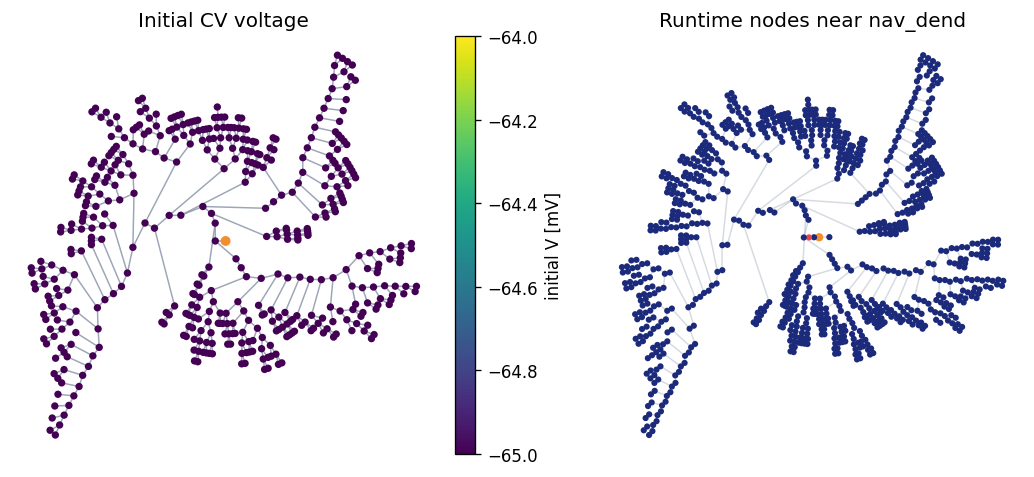

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
cell.vis_cv(value="V", cmap="viridis", value_label="initial V", ax=axes[0], show=False)
axes[0].set_title("Initial CV voltage")
cell.vis_node(region=regions["nav_dend"], coverage_mode="any", ax=axes[1], show=False)
axes[1].set_title("Runtime nodes near nav_dend")
plt.tight_layout()
plt.show()

## 11. 运行模型

现在模型已经初始化并 reset 到初始状态。运行后检查 trace key、shape、有限数值范围，再画 soma voltage。

In [17]:
run = cell.run(dt=dt_ms * u.ms, duration=duration_ms * u.ms)

v_soma = np.asarray(run.traces["v_soma"].to_decimal(u.mV), dtype=float).reshape(-1)
time_ms = (np.arange(v_soma.shape[0], dtype=float) + 1.0) * dt_ms

print("trace keys:", sorted(run.traces.keys()))
print("v_soma shape:", v_soma.shape)
print("finite:", bool(np.all(np.isfinite(v_soma))))
print("v_soma min/max (mV):", float(np.nanmin(v_soma)), float(np.nanmax(v_soma)))

trace keys: ['v_soma']
v_soma shape: (200,)
finite: True
v_soma min/max (mV): -71.66093648742991 23.271882978957784


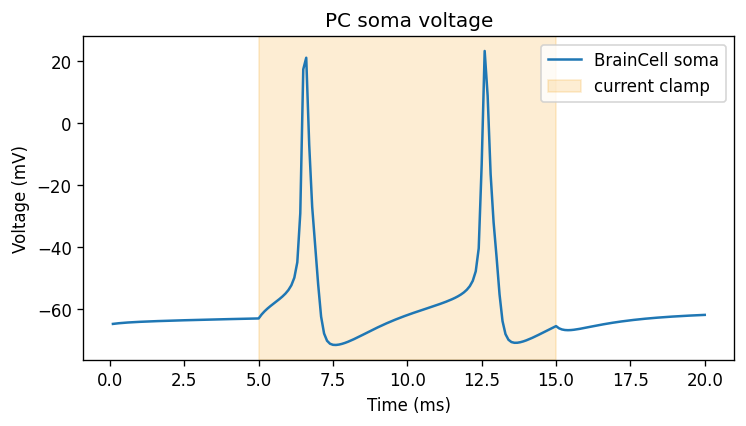

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(time_ms, v_soma, label="BrainCell soma")
ax.axvspan(delay_ms, delay_ms + stim_dur_ms, color="#f59e0b", alpha=0.18, label="current clamp")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (mV)")
ax.set_title("PC soma voltage")
ax.legend()
plt.show()

## 12. 对照正式模板

这个 notebook 的构建顺序和 `pc_braincell.py` 保持一致，但这里每一步都暴露中间对象，适合作为复杂树突模型的教学入口。正式比较或复用时仍然使用 `pc_braincell.PC(...).build()`。